In [51]:
import pandas as pd
import matplotlib as plt
import plotly.express as px
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score, auc,confusion_matrix, f1_score,precision_score, classification_report

In [55]:
PATH = "../../data/TreatedData/TreatedData.csv"

df = pd.read_csv(PATH)

In [56]:
df.head()

,Unnamed: 0,0,X_0,Y_0,Z_0,X_1,Y_1,Z_1,X_2,Y_2,Z_2,X_3,Y_3,Z_3,X_4,Y_4,Z_4,X_5,Y_5,Z_5,X_6,Y_6,Z_6,X_7,Y_7,Z_7,X_8,Y_8,Z_8,X_9,Y_9,Z_9,X_10,Y_10,Z_10,X_11,Y_11,Z_11,X_12,Y_12,...,Z_454,X_455,Y_455,Z_455,X_456,Y_456,Z_456,X_457,Y_457,Z_457,X_458,Y_458,Z_458,X_459,Y_459,Z_459,X_460,Y_460,Z_460,X_461,Y_461,Z_461,X_462,Y_462,Z_462,X_463,Y_463,Z_463,X_464,Y_464,Z_464,X_465,Y_465,Z_465,X_466,Y_466,Z_466,X_467,Y_467,Z_467
0,44782,3,0.480316,0.522955,-0.038981,0.483750,0.496124,-0.083564,0.483050,0.503859,-0.042683,0.475757,0.465541,-0.064984,0.485188,0.487161,-0.089554,0.487187,0.475036,-0.084431,0.492451,0.446320,-0.046293,0.388895,0.436683,0.019214,0.494929,0.430244,-0.038373,0.496744,0.419612,-0.042916,0.505951,0.372816,-0.028657,0.479678,0.527088,-0.036402,0.479345,0.529566,...,0.160087,0.532227,0.498953,-0.036949,0.513438,0.471603,-0.053727,0.509061,0.495794,-0.074835,0.499977,0.499207,-0.068065,0.509228,0.496906,-0.067093,0.527451,0.501011,-0.031450,0.496764,0.500002,-0.072189,0.495518,0.501285,-0.053261,0.531213,0.446296,0.006642,0.522294,0.447785,-0.002943,0.517716,0.449075,-0.014746,0.599552,0.448041,0.013785,0.607134,0.447017,0.013783
1,44783,3,0.481082,0.523268,-0.039329,0.484299,0.496527,-0.083353,0.483830,0.504162,-0.042776,0.476545,0.465905,-0.064385,0.485712,0.487608,-0.089165,0.487838,0.475485,-0.083926,0.493360,0.446721,-0.045307,0.390942,0.436650,0.019621,0.495852,0.430440,-0.036797,0.497654,0.419943,-0.041123,0.506569,0.374581,-0.026297,0.480467,0.527387,-0.036723,0.480140,0.529841,...,0.159443,0.532695,0.499490,-0.036933,0.514236,0.472041,-0.053223,0.509668,0.496281,-0.074579,0.500648,0.499616,-0.067896,0.509818,0.497361,-0.066889,0.528024,0.501519,-0.031516,0.497484,0.500423,-0.072011,0.496205,0.501672,-0.053212,0.532480,0.446590,0.007599,0.523368,0.448136,-0.002009,0.518714,0.449448,-0.013882,0.602053,0.447774,0.014899,0.609231,0.446963,0.014788
2,44784,3,0.481146,0.523485,-0.038708,0.484601,0.496378,-0.083276,0.484121,0.504084,-0.042318,0.476842,0.465909,-0.064851,0.485982,0.487491,-0.089291,0.488098,0.475413,-0.084286,0.493674,0.446779,-0.046363,0.391536,0.436983,0.019322,0.496249,0.430530,-0.038502,0.498031,0.420017,-0.043169,0.507083,0.374571,-0.029414,0.480469,0.527602,-0.036053,0.480173,0.530041,...,0.158366,0.532691,0.499389,-0.036946,0.514509,0.472014,-0.053860,0.509858,0.496077,-0.074680,0.500861,0.499417,-0.067837,0.510021,0.497157,-0.066963,0.527950,0.501445,-0.031378,0.497711,0.500232,-0.071904,0.496440,0.501490,-0.052995,0.532861,0.446563,0.006097,0.523769,0.448124,-0.003379,0.519100,0.449453,-0.015091,0.602179,0.447891,0.012867,0.609452,0.447104,0.012700
3,44785,3,0.481022,0.522546,-0.038745,0.484630,0.496284,-0.083493,0.484004,0.503810,-0.042262,0.476863,0.465838,-0.065227,0.486065,0.487420,-0.089550,0.488222,0.475365,-0.084586,0.493835,0.446811,-0.046927,0.390514,0.436708,0.018738,0.496357,0.430771,-0.039502,0.498186,0.420309,-0.044384,0.507503,0.374545,-0.031038,0.480326,0.526666,-0.036134,0.480002,0.529215,...,0.159391,0.533031,0.499300,-0.036928,0.514830,0.471971,-0.054113,0.510083,0.496043,-0.074837,0.500984,0.499358,-0.067949,0.510244,0.497133,-0.067093,0.528213,0.501317,-0.031317,0.497810,0.500153,-0.072042,0.496484,0.501366,-0.053045,0.533518,0.446631,0.005659,0.524328,0.448171,-0.003889,0.519563,0.449490,-0.015583,0.603138,0.447989,0.012720,0.610540,0.447074,0.012577
4,44786,3,0.481739,0.523413,-0.039082,0.485431,0.496454,-0.084576,0.484669,0.504108,-0.043229,0.477020,0.465747,-0.066017,0.486792,0.487531,-0.090684,0.488804,0.475377,-0.085591,0.494059,0.446461,-0.047249,0.389301,0.436610,0.018970,0.496644,0.430211,-0.039272,0.498499,0.419620,-0.043914,0.507549,0.373634,-0.029915,0.481060,0.527601,-0.036266,0.480715,0.530159,...,0.161461,0.535807,0.499217,-0.037413,0.515845,0.471834,-0.054576,0.511660,0.496115,-0.075772,0.502317,0.499491,-0.068881,0.511887,0.497196,-0.067939,0.530902,0.501278,-0.031831,0.498964,0.500316,-0.073039,0.497729,0.501559,-0.053857,0.533855,0.446192,0.006359,0.52468

In [ ]:
del df["Unnamed: 0"]

KeyError: "['Unnamed: 0'] not found in axis"

In [16]:
X = df.iloc[:,1:]
y = df.iloc[:,0]


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=42)



In [52]:
clf = LinearSVC()

clf

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [53]:
clf.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


              precision    recall  f1-score   support

    Classe 3       0.93      0.97      0.95      4680
    Classe 4       0.97      0.93      0.95      5060

    accuracy                           0.95      9740
   macro avg       0.95      0.95      0.95      9740
weighted avg       0.95      0.95      0.95      9740



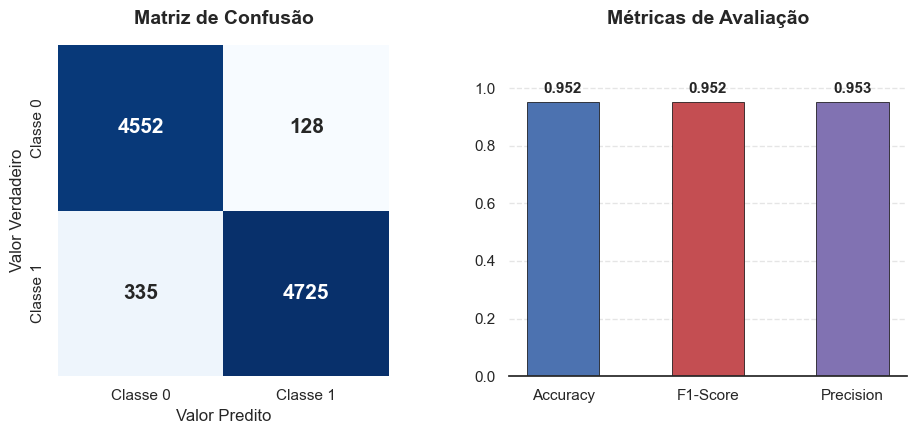

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. Substitua por suas métricas reais
# ==========================================


y_pred = clf.predict(X_test)



report = classification_report(
    y_test,
    y_pred,
    labels=[3, 4],
    target_names=['Classe 3', 'Classe 4'],
)

print(report)

accuracy = accuracy_score(y_test, y_pred)    
f1_val = f1_score(y_test,y_pred, average="macro", zero_division=0)        
precision_val = precision_score(y_test,y_pred, average="macro", zero_division=0)   

cm = confusion_matrix(y_test,y_pred, labels=[3,4])
class_labels = ['Classe 0', 'Classe 1'] 

# ==========================================
# 2. Configuração Visual
# ==========================================
sns.set_theme(style="white")
# Proporção reajustada para 3 barras ficarem harmônicas
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), gridspec_kw={'width_ratios': [1.3, 1]})

# ==========================================
# 3. Matriz de Confusão (Esquerda)
# ==========================================
sns.heatmap(
    cm, 
    annot=True,          
    fmt="d",             
    cmap="Blues",        
    cbar=False,          
    square=True,         
    xticklabels=class_labels, 
    yticklabels=class_labels,
    annot_kws={"size": 15, "weight": "bold"},
    ax=axes[0]
)

axes[0].set_title('Matriz de Confusão', fontsize=14, pad=15, fontweight='bold')
axes[0].set_xlabel('Valor Predito', fontsize=12)
axes[0].set_ylabel('Valor Verdadeiro', fontsize=12)

# ==========================================
# 4. Gráfico de Métricas (Direita)
# ==========================================
nomes = ['Accuracy', 'F1-Score', 'Precision']
valores = [accuracy, f1_val, precision_val]

# Cores: Azul, Vermelho-mudo e Roxo (removido o verde)
cores = ['#4C72B0', '#C44E52', '#8172B2'] 

bars = axes[1].bar(nomes, valores, color=cores, width=0.5, edgecolor='black', linewidth=0.5)

# Adiciona o texto com os valores em cima de cada barra
for bar in bars:
    yval = bar.get_height()
    
    axes[1].text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.02, 
        f'{yval:.3f}', 
        ha='center', 
        va='bottom', 
        fontsize=11,
        fontweight='bold'
    )

axes[1].set_title('Métricas de Avaliação', fontsize=14, pad=15, fontweight='bold')
axes[1].set_ylim(0, 1.15) 
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Limpando bordas (Estilo minimalista)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].tick_params(left=False) 

plt.tight_layout()
plt.show()


In [50]:
import joblib

joblib.dump(clf,"clf_predict.pkl")


['clf_predict.pkl']